In [20]:
"""
    goal : create a full precision baseline(Qwen2-VL-7B-Instruct fp16) that is as close to the paper results
    success criteria : % interpretable in ~49–70% across layers

    index : McGill-NLP/latentlens-qwen2vl-embeddings
    data:
        first 100 images from created pixmo cap val set
        from each image, 1 patch/visual token is sampled 
        this is done for each layer (each layer sees the same image but a different visual token)
        and for each layer a % interpretable is calculated and reported

    mid layer leap check - without judge, compare your results against the paper
    judging method: input - full image with a 3x3 box around the patch/visual token and top 5 words

    my hypothesis metrics to track
    - for each word extracted, track min_depth; among top5, keep track of top 1 noun

    - creating layer wise dataset should be fixed across different arms

    steps:
    - load val set, index, model
    - pick 100 samples
    - create layer wise dataset
        - pick 1 patch/visual token from each sample for each layer
        - create a 3x3 box around the patch/visual token
    - find top 5 words for each sample from above, note metadata and record the hypernym hypothesis metrics
    - mid layer leap plot
    - judge : for later

"""

# Autoreload
%load_ext autoreload
%autoreload 2

import gc
import ctypes
import csv
import json
import random
import subprocess
import sys
from pathlib import Path
from dataclasses import dataclass

import requests
from PIL import Image
import datasets
import numpy as np
import torch
from io import BytesIO
from matplotlib import pyplot as plt
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration


# load images
num_images = 5
FIXED_RESOLUTION = 448  # → 16×16 merged token grid (256 visual tokens)
seed = 42
_HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; research-bot/1.0)"}
VISUAL_LAYERS = [1, 2, 4, 8, 16, 24, 27]


def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def gc_cuda():
    """Gargage collect RAM & Torch (CUDA) memory."""
    gc.collect()
    if torch.cuda.is_available():
        ctypes.CDLL("libc.so.6").malloc_trim(0)
        torch.cuda.empty_cache()

seed = 42
seed_all(seed)

def _ensure_nlp_resources():
    print("\nChecking NLP resources...")
    import nltk
    try:
        wn = __import__("nltk.corpus", fromlist=["wordnet"]).wordnet
        wn.synsets("dog")
    except Exception:
        print("  Downloading NLTK wordnet + omw-1.4...")
        nltk.download("wordnet", quiet=True)
        nltk.download("omw-1.4", quiet=True)

    try:
        import spacy
        spacy.load("en_core_web_sm")
    except OSError:
        print("  Downloading spaCy en_core_web_sm...")
        subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)

    print("  NLP resources OK")

_ensure_nlp_resources()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Checking NLP resources...
  NLP resources OK


Examples : 100
Columns  : ['val_idx', 'image_url', 'caption', 'transcripts', 'image']
val_idx  : 0 … 105

Example 0
  val_idx   : 0
  image size: (626, 417)  mode: RGB
  image_url : https://img.freepik.com/premium-photo/red-kidney-bean-is-variety-common-bean-woo...
  caption   : This image showcases a detailed, aesthetic, top-down view of a wooden bowl filled to the brim with approximately one or ...
  transcripts: 3 item(s)


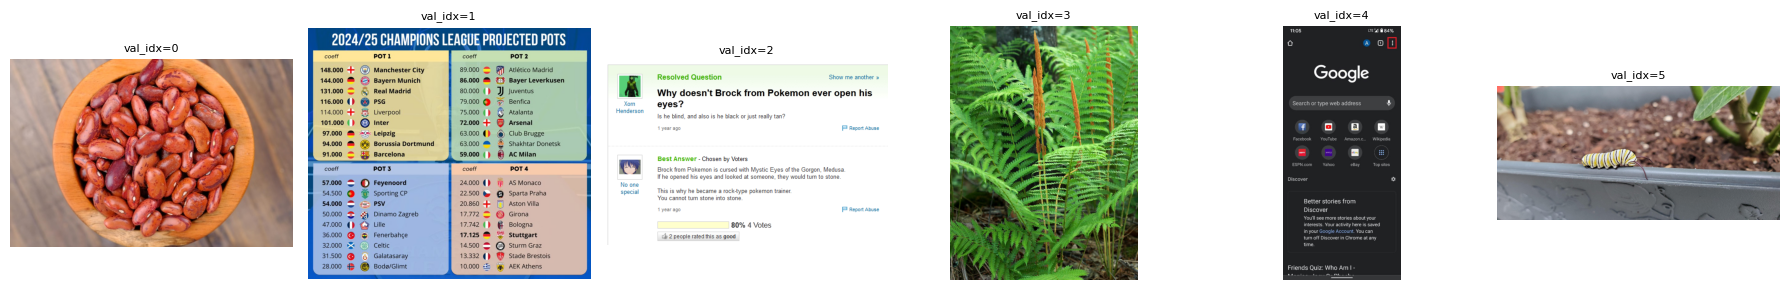

  Loading layer 1 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 2 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 4 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 8 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 16 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 24 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 26 from embeddings_cache.pt... shape=[300836, 3584] dtype=torch.float16
  Loading layer 27 from embeddings_cache.pt... 

`torch_dtype` is deprecated! Use `dtype` instead!


shape=[300836, 3584] dtype=torch.float16


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


  Loaded model on cuda:0, resolution locked to 448×448


In [5]:
# load val set, index, model

model_dir = Path("/workspace/latentlens/experiment/data/Qwen2-VL-7B-Instruct")
index_dir = Path("/workspace/latentlens/experiment/data/latentlens-qwen2vl-embeddings")
data_dir = Path('/workspace/latentlens/experiment/data/pixmo_cap_val100')

def load_data():
    ds_val100 = datasets.load_dataset(
        "parquet",
        data_files={"validation": str(data_dir / "data" / "validation-*.parquet")},
    )["validation"]

    print(f"Examples : {len(ds_val100)}")
    print(f"Columns  : {ds_val100.column_names}")
    print(f"val_idx  : {ds_val100[0]['val_idx']} … {ds_val100[-1]['val_idx']}")

    # Spot-check first example
    ex = ds_val100[0]
    img: Image.Image = ex["image"]
    print(f"\nExample 0")
    print(f"  val_idx   : {ex['val_idx']}")
    print(f"  image size: {img.size}  mode: {img.mode}")
    print(f"  image_url : {ex['image_url'][:80]}...")
    print(f"  caption   : {ex['caption'][:120].replace(chr(10), ' ')}...")
    print(f"  transcripts: {len(ex['transcripts'])} item(s)")

    # Quick grid preview of first 6 images
    fig, axes = plt.subplots(1, 6, figsize=(18, 3))
    for i, ax in enumerate(axes):
        ax.imshow(ds_val100[i]["image"])
        ax.set_title(f"val_idx={ds_val100[i]['val_idx']}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    return ds_val100

@dataclass
class Bank:
    embeddings: torch.Tensor   # [N, hidden_dim] float16, kept on CPU
    metadata: list             # [{token_str, token_id, caption, position}, ...]


def load_banks(index_dir: Path, layers: list = None) -> dict:
    """Load reference embedding banks. Returns {layer: Bank}.
    If layers is None, loads all available layer_* directories."""
    if layers is None:
        layers = sorted(
            int(p.name.split("_")[1])
            for p in index_dir.iterdir()
            if p.is_dir() and p.name.startswith("layer_")
        )

    banks = {}
    for L in layers:
        path = index_dir / f"layer_{L}" / "embeddings_cache.pt"
        print(f"  Loading layer {L} from {path.name}...", end=" ", flush=True)
        data = torch.load(path, map_location="cpu", weights_only=False)
        banks[L] = Bank(embeddings=data["embeddings"], metadata=data["metadata"])
        e = data["embeddings"]
        print(f"shape={list(e.shape)} dtype={e.dtype}")

    return banks

def load_model(model_dir: Path):
    model = Qwen2VLForConditionalGeneration.from_pretrained(
        str(model_dir), torch_dtype=torch.float16, device_map="auto"
    )

    model.eval()

    processor = AutoProcessor.from_pretrained(str(model_dir))
    px = FIXED_RESOLUTION * FIXED_RESOLUTION
    processor.image_processor.min_pixels = px
    processor.image_processor.max_pixels = px
    processor.image_processor.do_resize = False

    print(f"  Loaded model on {model.device}, resolution locked to {FIXED_RESOLUTION}×{FIXED_RESOLUTION}")
    return model, processor

data = load_data()
banks = load_banks(index_dir)
model, processor= load_model(model_dir)





In [6]:
import gc
import sys
from tqdm import tqdm
from datasets import Dataset, Features, Sequence, Value

_EVAL_UTILS = Path("/workspace/latentlens/reproduce/scripts/evaluate")
if str(_EVAL_UTILS) not in sys.path:
    sys.path.insert(0, str(_EVAL_UTILS))
from utils import sample_valid_patch_positions

IMAGE_PAD_TOKEN_ID = 151655  # <|image_pad|> in Qwen2-VL vocabulary
PROMPT = "<|image_pad|>Describe this image."
GRID_SIZE = 16
BBOX_SIZE = 3
PROCESSED_SIZE = 512  # judge preprocessing canvas (center-crop, no padding)


def create_layer_wise_dataset(
    data: datasets.Dataset,
    model,
    processor,
    visual_layers: list[int] | None = None,
    seed: int = 42,
) -> datasets.Dataset:
    """Build layer-wise HF dataset: one row per (image, layer) with hidden state + patch coords.

    Patch selection matches evaluate_interpretability.py: seed once, then layers outer,
    images inner, sampling one valid 3x3 top-left position per (layer, image).
    """
    visual_layers = visual_layers or VISUAL_LAYERS
    image_mask = np.ones((PROCESSED_SIZE, PROCESSED_SIZE), dtype=bool)

    # Phase A: pre-compute patch assignments (CPU-only)
    random.seed(seed)
    assignments: dict[tuple[int, int], tuple[int, int]] = {}
    for layer in visual_layers:
        for example in data:
            val_idx = int(example["val_idx"])
            positions = sample_valid_patch_positions(
                image_mask,
                bbox_size=BBOX_SIZE,
                num_samples=1,
                grid_size=GRID_SIZE,
            )
            if not positions:
                raise RuntimeError(
                    f"No valid patch positions for val_idx={val_idx}, layer={layer}"
                )
            assignments[(layer, val_idx)] = positions[0]

    print(
        f"Pre-computed {len(assignments)} patch assignments "
        f"({len(data)} images x {len(visual_layers)} layers)"
    )

    # Phase B: one forward pass per image, extract hidden states for all layers
    rows: list[dict] = []
    for example in tqdm(data, desc="Extracting hidden states"):
        val_idx = int(example["val_idx"])
        img = example["image"].resize((FIXED_RESOLUTION, FIXED_RESOLUTION))
        inputs = processor(
            text=PROMPT,
            images=[img],
            return_tensors="pt",
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        vision_positions = (inputs["input_ids"][0] == IMAGE_PAD_TOKEN_ID).nonzero(as_tuple=True)[0]
        if len(vision_positions) == 0:
            raise RuntimeError(f"No vision tokens found for val_idx={val_idx}")
        vision_start = int(vision_positions[0])

        for layer in visual_layers:
            if layer >= len(outputs.hidden_states):
                tqdm.write(
                    f"  Warning: layer={layer} out of range "
                    f"({len(outputs.hidden_states)} hidden states); skipping"
                )
                continue

            patch_row, patch_col = assignments[(layer, val_idx)]
            center_row = patch_row + BBOX_SIZE // 2
            center_col = patch_col + BBOX_SIZE // 2
            patch_token_idx = center_row * GRID_SIZE + center_col

            hs = (
                outputs.hidden_states[layer][0, vision_start + patch_token_idx, :]
                .float()
                .cpu()
                .numpy()
                .astype(np.float16)
            )

            rows.append(
                {
                    "val_idx": val_idx,
                    "layer": layer,
                    "patch_row": patch_row,
                    "patch_col": patch_col,
                    "center_row": center_row,
                    "center_col": center_col,
                    "patch_token_idx": patch_token_idx,
                    "hidden_state": hs,
                }
            )

        del outputs, inputs
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    features = Features(
        {
            "val_idx": Value("int32"),
            "layer": Value("int32"),
            "patch_row": Value("int32"),
            "patch_col": Value("int32"),
            "center_row": Value("int32"),
            "center_col": Value("int32"),
            "patch_token_idx": Value("int32"),
            "hidden_state": Sequence(Value("float16"), length=3584),
        }
    )
    ds = Dataset.from_list(rows, features=features)
    print(f"Created layer-wise dataset: {len(ds)} rows")
    return ds


In [7]:
from collections import Counter

# each candidate image passed through the model and the hidden states are extracted for each layer
ds_layer_wise = create_layer_wise_dataset(data, model, processor, seed=seed)

print(f"\nRows: {len(ds_layer_wise)} (expected {len(data) * len(VISUAL_LAYERS)})")
print(f"Columns: {ds_layer_wise.column_names}")

ex = ds_layer_wise[0]
print("\nSample row:")
print(f"  val_idx={ex['val_idx']}  layer={ex['layer']}")
print(f"  patch=({ex['patch_row']}, {ex['patch_col']})  center=({ex['center_row']}, {ex['center_col']})")
print(f"  patch_token_idx={ex['patch_token_idx']}")
hs = np.asarray(ex["hidden_state"])
print(f"  hidden_state shape={hs.shape} dtype={hs.dtype}")

layer_counts = Counter(ds_layer_wise["layer"])
print(f"\nRows per layer: {dict(sorted(layer_counts.items()))}")

# Sanity: same image should have different patches across layers
sample_val_idx = ds_layer_wise[0]["val_idx"]
patches_by_layer = {
    row["layer"]: (row["patch_row"], row["patch_col"])
    for row in ds_layer_wise
    if row["val_idx"] == sample_val_idx
}
print(f"\nPatches for val_idx={sample_val_idx} across layers:")
for layer in sorted(patches_by_layer):
    print(f"  layer {layer}: {patches_by_layer[layer]}")


Pre-computed 700 patch assignments (100 images x 7 layers)


Extracting hidden states: 100%|██████████| 100/100 [00:48<00:00,  2.05it/s]


Created layer-wise dataset: 700 rows

Rows: 700 (expected 700)
Columns: ['val_idx', 'layer', 'patch_row', 'patch_col', 'center_row', 'center_col', 'patch_token_idx', 'hidden_state']

Sample row:
  val_idx=0  layer=1
  patch=(11, 9)  center=(12, 10)
  patch_token_idx=202
  hidden_state shape=(3584,) dtype=float64

Rows per layer: {1: 100, 2: 100, 4: 100, 8: 100, 16: 100, 24: 100, 27: 100}

Patches for val_idx=0 across layers:
  layer 1: (11, 9)
  layer 2: (6, 13)
  layer 4: (8, 13)
  layer 8: (9, 11)
  layer 16: (11, 5)
  layer 24: (3, 3)
  layer 27: (7, 5)


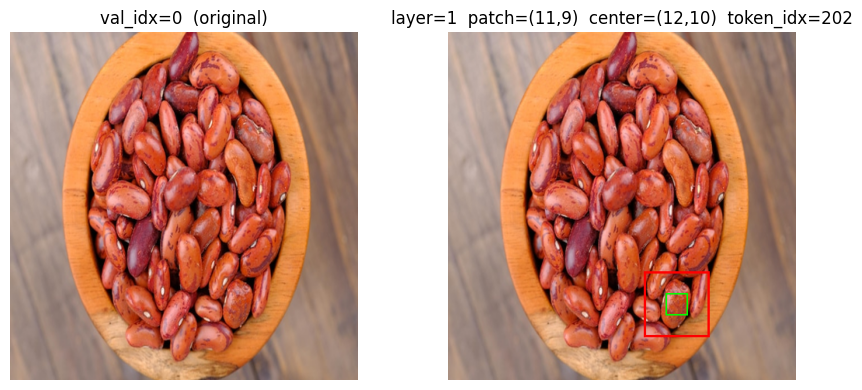

val_idx        : 0
layer          : 1
patch_row/col  : (11, 9)
center_row/col : (12, 10)
patch_token_idx: 202
bbox px        : (252, 308, 336, 392) on 448x448
hidden_state   : shape=(3584,)  norm=40.457  mean=0.0123


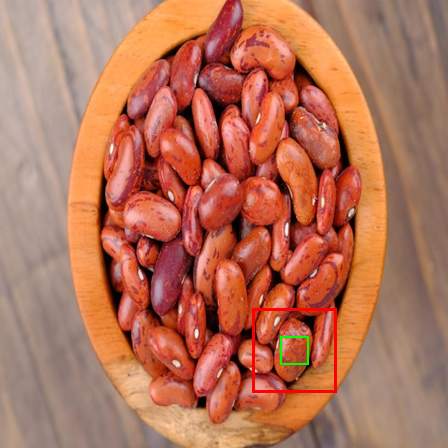

In [8]:
from copy import deepcopy
from PIL import ImageDraw


def _image_by_val_idx(images: datasets.Dataset) -> dict[int, Image.Image]:
    return {int(ex["val_idx"]): ex["image"] for ex in images}


def show_layer_wise_row(
    row,
    images: datasets.Dataset,
    *,
    ds_layer_wise: datasets.Dataset | None = None,
    image_lookup: dict[int, Image.Image] | None = None,
    show_hidden_stats: bool = True,
):
    """Display a layer-wise dataset row with its image and 3x3 patch bbox.

    Args:
        row: Row dict, or integer index into ds_layer_wise.
        images: val100 dataset with embedded PIL images.
        ds_layer_wise: Required if row is an integer index.
        image_lookup: Optional pre-built {val_idx: image} map.
        show_hidden_stats: Print hidden-state norm stats.
    """
    if isinstance(row, int):
        if ds_layer_wise is None:
            raise ValueError("ds_layer_wise is required when row is an index")
        row = ds_layer_wise[row]

    lookup = image_lookup or _image_by_val_idx(images)
    val_idx = int(row["val_idx"])
    if val_idx not in lookup:
        raise KeyError(f"val_idx={val_idx} not found in images dataset")

    img = lookup[val_idx].resize((FIXED_RESOLUTION, FIXED_RESOLUTION)).convert("RGB")
    merged_patch_px = FIXED_RESOLUTION // GRID_SIZE

    patch_row = int(row["patch_row"])
    patch_col = int(row["patch_col"])
    center_row = int(row["center_row"])
    center_col = int(row["center_col"])

    # 3x3 bbox (top-left of sampled position)
    x1 = patch_col * merged_patch_px
    y1 = patch_row * merged_patch_px
    x2 = (patch_col + BBOX_SIZE) * merged_patch_px
    y2 = (patch_row + BBOX_SIZE) * merged_patch_px

    # center merged patch
    cx1 = center_col * merged_patch_px
    cy1 = center_row * merged_patch_px
    cx2 = (center_col + 1) * merged_patch_px
    cy2 = (center_row + 1) * merged_patch_px

    vis = deepcopy(img)
    draw = ImageDraw.Draw(vis)
    draw.rectangle((x1, y1, x2, y2), outline="red", width=3)
    draw.rectangle((cx1, cy1, cx2, cy2), outline="lime", width=2)

    # Make figure a bit smaller
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(img)
    axes[0].set_title(f"val_idx={val_idx}  (original)")
    axes[0].axis("off")

    axes[1].imshow(vis)
    axes[1].set_title(
        f"layer={row['layer']}  patch=({patch_row},{patch_col})  "
        f"center=({center_row},{center_col})  token_idx={row['patch_token_idx']}"
    )
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"val_idx        : {val_idx}")
    print(f"layer          : {row['layer']}")
    print(f"patch_row/col  : ({patch_row}, {patch_col})")
    print(f"center_row/col : ({center_row}, {center_col})")
    print(f"patch_token_idx: {row['patch_token_idx']}")
    print(f"bbox px        : ({x1}, {y1}, {x2}, {y2}) on {FIXED_RESOLUTION}x{FIXED_RESOLUTION}")

    if show_hidden_stats:
        hs = np.asarray(row["hidden_state"], dtype=np.float32)
        print(f"hidden_state   : shape={hs.shape}  norm={np.linalg.norm(hs):.3f}  mean={hs.mean():.4f}")

    return vis


# Example: show row 0
show_layer_wise_row(0, data, ds_layer_wise=ds_layer_wise)


In [21]:
# for each sample, find top 5 words and record metadata and hypernym metrics

import sys
_QLLENS_SRC = Path("/workspace/latentlens/experiment/qllens/src")
if str(_QLLENS_SRC) not in sys.path:
    sys.path.insert(0, str(_QLLENS_SRC))
from nn_search import search as _nn_search

# Hidden states are already extracted — free the model to make room for bank embeddings
del model, processor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Model freed.")

TOP_K = 5
_NN_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"NN search device: {_NN_DEVICE}")


def get_nn_results(
    ds_layer_wise: datasets.Dataset,
    banks: dict,
    top_k: int = TOP_K,
) -> list[dict]:
    """Top-k NN search across all reference banks for every row in ds_layer_wise.

    Returns list[dict] with keys: val_idx, layer, top5_words, top5_nn_layers,
    top5_similarities, top5_captions.
    top5_nn_layers records which reference bank layer each neighbor came from —
    used directly to build the mid-layer leap matrix.
    """
    results = []
    for row in tqdm(ds_layer_wise, desc="NN search"):
        hs = torch.tensor(np.asarray(row["hidden_state"], dtype=np.float32))
        neighbors = _nn_search(hs, banks, top_k=top_k, device=_NN_DEVICE)
        results.append({
            "val_idx":           int(row["val_idx"]),
            "layer":             int(row["layer"]),
            "top5_words":        [n.token_str for n in neighbors],
            "top5_nn_layers":    [n.contextual_layer for n in neighbors],
            "top5_similarities": [round(n.similarity, 4) for n in neighbors],
            "top5_captions":     [n.caption for n in neighbors],
        })
    return results


nn_results = get_nn_results(ds_layer_wise, banks)
print(f"nn_results: {len(nn_results)} rows")
# Sanity: show first result
r = nn_results[0]
print(f"val_idx={r['val_idx']}  layer={r['layer']}")
print(f"  words        : {r['top5_words']}")
print(f"  nn_layers    : {r['top5_nn_layers']}")
print(f"  similarities : {r['top5_similarities']}")

Model freed.
NN search device: cuda


NN search: 100%|██████████| 700/700 [20:48<00:00,  1.78s/it]

nn_results: 700 rows
val_idx=0  layer=1
  words        : [' brown', ' brown', ' brown', ' brown', ' matte']
  nn_layers    : [2, 1, 1, 1, 1]
  similarities : [0.2432, 0.2397, 0.2335, 0.2333, 0.2316]


In [22]:
results_dir = Path("/workspace/latentlens/experiment/data/results")
results_dir.mkdir(parents=True, exist_ok=True)
out_path = results_dir / "nn_results_fp16.json"
with open(out_path, "w") as f:
    json.dump(nn_results, f)
print(f"Saved {len(nn_results)} rows → {out_path}")


Saved 700 rows → /workspace/latentlens/experiment/data/results/nn_results_fp16.json


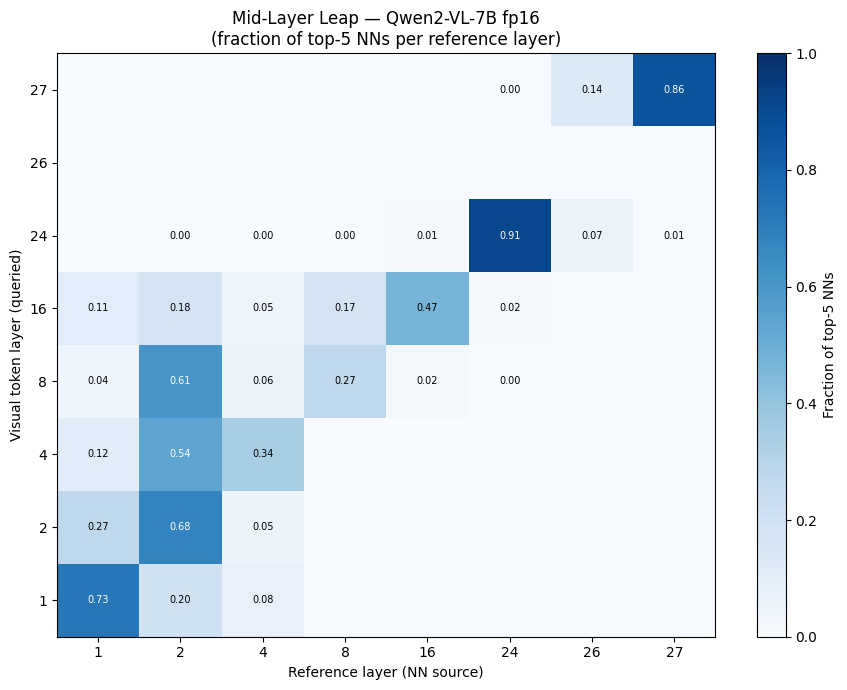

Saved → /workspace/latentlens/experiment/data/results/mid_layer_leap_fp16.png


In [25]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path


# Load results (works after a kernel restart too)
_results_path = Path("/workspace/latentlens/experiment/data/results/nn_results_fp16.json")
with open(_results_path) as f:
    nn_results = json.load(f)

# ── Build mid-layer leap matrix ──────────────────────────────────────────────
# Rows = visual token layer (queried), Cols = reference bank layer (NN source)
# Cell value = mean fraction of top-5 NNs drawn from that reference layer,
#              averaged over all samples with the same visual layer.

queried_layers = sorted({r["layer"] for r in nn_results})
ref_layers     = sorted({L for r in nn_results for L in r["top5_nn_layers"]})
all_layers     = sorted(set(queried_layers) | set(ref_layers))  # same sequence for both axes

# accumulate fractions per (visual_layer, ref_layer)
counts: dict[tuple, list] = defaultdict(list)
for r in nn_results:
    top5 = r["top5_nn_layers"]
    vl   = r["layer"]
    for rl in ref_layers:
        counts[(vl, rl)].append(top5.count(rl) / len(top5))

# build square matrix over all_layers; rows not in queried_layers stay 0
matrix = np.zeros((len(all_layers), len(all_layers)))
for i, vl in enumerate(all_layers):
    if vl not in queried_layers:
        continue
    for j, rl in enumerate(all_layers):
        vals = counts.get((vl, rl), [])
        matrix[i, j] = np.mean(vals) if vals else 0.0

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(matrix, aspect="auto", cmap="Blues", vmin=0, vmax=1, origin="lower")
fig.colorbar(im, ax=ax, label="Fraction of top-5 NNs")

ax.set_xticks(range(len(all_layers)))
ax.set_xticklabels(all_layers)
ax.set_yticks(range(len(all_layers)))
ax.set_yticklabels(all_layers)

ax.set_xlabel("Reference layer (NN source)")
ax.set_ylabel("Visual token layer (queried)")
ax.set_title("Mid-Layer Leap — Qwen2-VL-7B fp16\n(fraction of top-5 NNs per reference layer)")

# annotate cells with values (skip unqueried rows)
for i, vl in enumerate(all_layers):
    for j, rl in enumerate(all_layers):
        v = matrix[i, j]
        if v > 0:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if v > 0.5 else "black")

plt.tight_layout()
fig_path = Path("/workspace/latentlens/experiment/data/results/mid_layer_leap_fp16.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved → {fig_path}")


In [28]:
1

1

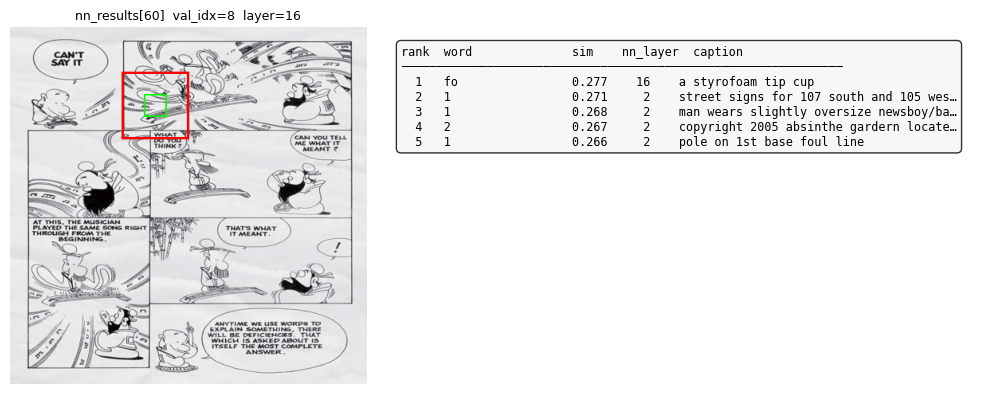

In [38]:
from copy import deepcopy
from PIL import ImageDraw

# Build lookups once (reusable across calls)
_nn_lookup    = {(r["val_idx"], r["layer"]): r   for r in nn_results}
_patch_lookup = {(int(row["val_idx"]), int(row["layer"])): row for row in ds_layer_wise}
_img_lookup   = {int(ex["val_idx"]): ex["image"] for ex in data}


def _draw_bbox(img, patch_row, patch_col, center_row, center_col,
               grid_size=16, bbox_size=3, res=448):
    px = res // grid_size
    vis = deepcopy(img.resize((res, res)).convert("RGB"))
    draw = ImageDraw.Draw(vis)
    draw.rectangle(
        (patch_col * px, patch_row * px,
         (patch_col + bbox_size) * px, (patch_row + bbox_size) * px),
        outline="red", width=3,
    )
    draw.rectangle(
        (center_col * px, center_row * px,
         (center_col + 1) * px, (center_row + 1) * px),
        outline="lime", width=2,
    )
    return vis


def show_nn_result(idx: int):
    """Visualize nn_results[idx]: image with patch bbox + top-5 NN table.

    Args:
        idx: index into nn_results (0 … len(nn_results)-1).
    """
    r    = nn_results[idx]
    key  = (r["val_idx"], r["layer"])
    prow = _patch_lookup[key]

    vis = _draw_bbox(
        _img_lookup[r["val_idx"]],
        int(prow["patch_row"]), int(prow["patch_col"]),
        int(prow["center_row"]), int(prow["center_col"]),
    )

    fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(11, 4),
                                          gridspec_kw={"width_ratios": [1, 1.6]})
    ax_img.imshow(vis)
    ax_img.set_title(
        f"nn_results[{idx}]  val_idx={r['val_idx']}  layer={r['layer']}",
        fontsize=9,
    )
    ax_img.axis("off")

    lines = ["rank  word              sim    nn_layer  caption"]
    lines.append("─" * 62)
    for rank, (word, sim, nl, cap) in enumerate(zip(
            r["top5_words"], r["top5_similarities"],
            r["top5_nn_layers"], r["top5_captions"]), 1):
        cap_short = cap[:38] + "…" if len(cap) > 38 else cap
        lines.append(f"  {rank}   {word:<16s}  {sim:.3f}    {nl:>2}    {cap_short}")

    ax_txt.axis("off")
    ax_txt.text(0.02, 0.95, "\n".join(lines),
                transform=ax_txt.transAxes,
                fontsize=8.5, verticalalignment="top", fontfamily="monospace",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5", alpha=0.8))

    plt.tight_layout()
    plt.show()


# Example
show_nn_result(60)